In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

data = {
    'age': [23, 25, 27, 29, 29],
    'likes english': [0, 1, 1, 0, 0],
    'likes ai': [0, 1, 0, 1, 0],
    'salary': [200, 400, 300, 500, 400]
}

df = pd.DataFrame(data)

X = df[['age', 'likes english', 'likes ai']].values
y = df[['salary']].values.reshape(-1, 1)

reg = DecisionTreeRegressor()

reg = reg.fit(X, y)

x_test = np.array([[27, 0, 1]])
predicted_salary = reg.predict(x_test)
predicted_salary

array([400.])

[Text(0.375, 0.875, 'age <= 24.0\nsquared_error = 10400.0\nsamples = 5\nvalue = 360.0'),
 Text(0.25, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 200.0'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'age <= 28.0\nsquared_error = 5000.0\nsamples = 4\nvalue = 400.0'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'likes ai <= 0.5\nsquared_error = 2500.0\nsamples = 2\nvalue = 350.0'),
 Text(0.125, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 300.0'),
 Text(0.375, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 400.0'),
 Text(0.75, 0.375, 'likes ai <= 0.5\nsquared_error = 2500.0\nsamples = 2\nvalue = 450.0'),
 Text(0.625, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 400.0'),
 Text(0.875, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 500.0')]

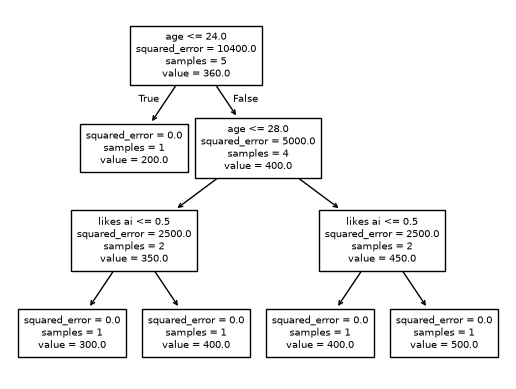

In [2]:
plot_tree(reg, feature_names=['age', 'likes english', 'likes ai'], fontsize=7)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import datasets

machine_cpu = datasets.fetch_openml(name = 'machine_cpu')

/opt/homebrew/Caskroom/miniconda/base/envs/learning/lib/python3.12/site-packages/sklearn/datasets/_openml.py:350: UserWarning: Multiple active versions of the dataset matching the name machine_cpu exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=230
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=733

  warn(warning_msg)


In [4]:
machine_cpu

{'data':      MYCT  MMIN   MMAX  CACH  CHMIN  CHMAX
 0     125   256   6000   256     16    128
 1      29  8000  32000    32      8     32
 2      29  8000  32000    32      8     32
 3      29  8000  32000    32      8     32
 4      29  8000  16000    32      8     16
 ..    ...   ...    ...   ...    ...    ...
 204   124  1000   8000     0      1      8
 205    98  1000   8000    32      2      8
 206   125  2000   8000     0      2     14
 207   480   512   8000    32      0      0
 208   480  1000   4000     0      0      0
 
 [209 rows x 6 columns],
 'target': 0      198
 1      269
 2      220
 3      172
 4      132
       ... 
 204     42
 205     46
 206     52
 207     67
 208     45
 Name: class, Length: 209, dtype: int64,
 'frame':      MYCT  MMIN   MMAX  CACH  CHMIN  CHMAX  class
 0     125   256   6000   256     16    128    198
 1      29  8000  32000    32      8     32    269
 2      29  8000  32000    32      8     32    220
 3      29  8000  32000    32      8     

In [5]:
x_data = machine_cpu.data
y_data = machine_cpu.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [7]:
y_test

30      274
171      30
84       22
198     915
60       16
155     326
45       72
181       6
9      1144
195     208
136      65
186     130
206      52
126      45
15       35
73       36
165      51
18       31
167     100
93      132
75       50
55       60
147     111
109      18
108      11
142      50
25       69
125      27
16       19
172      41
191     248
69       32
101      45
67       26
104      16
132      26
207      67
95      465
82       38
159      17
196     307
162      34
Name: class, dtype: int64

In [8]:
reg = DecisionTreeRegressor(max_depth=1)
reg = reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
y_pred

array([ 62.57142857,  62.57142857,  62.57142857, 370.5       ,
        62.57142857, 370.5       ,  62.57142857,  62.57142857,
       370.5       , 370.5       ,  62.57142857,  62.57142857,
        62.57142857,  62.57142857,  62.57142857,  62.57142857,
        62.57142857,  62.57142857,  62.57142857,  62.57142857,
        62.57142857,  62.57142857,  62.57142857,  62.57142857,
        62.57142857,  62.57142857,  62.57142857,  62.57142857,
        62.57142857,  62.57142857, 370.5       ,  62.57142857,
        62.57142857,  62.57142857,  62.57142857,  62.57142857,
        62.57142857, 370.5       ,  62.57142857,  62.57142857,
       370.5       ,  62.57142857])

In [9]:
mean_squared_error(y_pred, y_test)

24723.436224489797

[Text(0.5, 0.75, 'MMAX <= 28000.0\nsquared_error = 19224.451\nsamples = 167\nvalue = 99.449'),
 Text(0.25, 0.25, 'squared_error = 3396.98\nsamples = 147\nvalue = 62.571'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 52092.05\nsamples = 20\nvalue = 370.5'),
 Text(0.625, 0.5, '  False')]

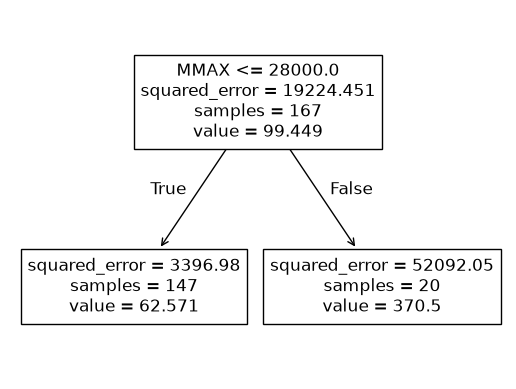

In [10]:
plot_tree(reg, feature_names=['MYCT',  'MMIN',   'MMAX',  'CACH',  'CHMIN',  'CHMAX'])

In [11]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [12]:
X = data.data
y = data.target

print(X.shape)
print(y)

(20640, 8)
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(y_test)

[0.477   0.458   5.00001 ... 5.00001 0.723   1.515  ]


In [15]:
from sklearn.tree import DecisionTreeRegressor
drg = DecisionTreeRegressor(max_depth=3)
drg = drg.fit(X_train, y_train)

y_pred = drg.predict(X_test)
y_pred

array([1.62582288, 1.16511993, 2.73565309, ..., 4.57673829, 1.16511993,
       1.86688424], shape=(4128,))

In [16]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_pred, y_test)

0.642410981026564

[Text(0.5, 0.875, 'MedInc <= 5.086\nsquared_error = 1.337\nsamples = 16512\nvalue = 2.072'),
 Text(0.25, 0.625, 'MedInc <= 3.074\nsquared_error = 0.834\nsamples = 13101\nvalue = 1.74'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'AveRooms <= 4.314\nsquared_error = 0.561\nsamples = 6268\nvalue = 1.358'),
 Text(0.0625, 0.125, 'squared_error = 0.679\nsamples = 2624\nvalue = 1.626'),
 Text(0.1875, 0.125, 'squared_error = 0.387\nsamples = 3644\nvalue = 1.165'),
 Text(0.375, 0.375, 'AveOccup <= 2.418\nsquared_error = 0.827\nsamples = 6833\nvalue = 2.09'),
 Text(0.3125, 0.125, 'squared_error = 1.248\nsamples = 1755\nvalue = 2.736'),
 Text(0.4375, 0.125, 'squared_error = 0.488\nsamples = 5078\nvalue = 1.867'),
 Text(0.75, 0.625, 'MedInc <= 6.888\nsquared_error = 1.218\nsamples = 3411\nvalue = 3.348'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'AveOccup <= 2.671\nsquared_error = 0.908\nsamples = 2384\nvalue = 2.954'),
 Text(0.5625, 0.125, 'squared_error = 1.012\nsamples = 860\nv

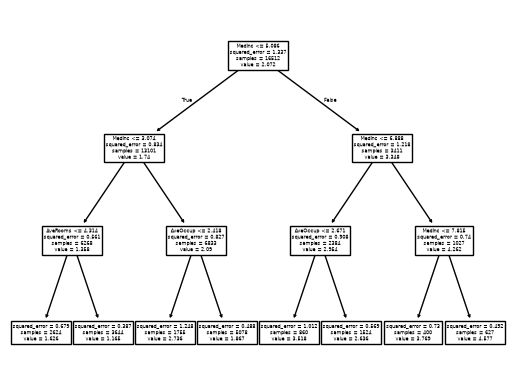

In [17]:
from sklearn.tree import plot_tree
plot_tree(drg, feature_names=['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'])